In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

In [25]:
molecules = ['heh+','h2']
bases = ['sto-3g','3-21g','6-31g','6-31gss']

gaplookup = {}
freqlookup = {}

mygaps = [(0,1),(0,2),(1,2),(0,3),(1,3),(2,3)]
allgapstr = []
for gap in mygaps:
    gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
    allgapstr.append(gapstr)

print(allgapstr)

for mol in molecules:
    for basis in bases:
        fname = './psi4data/fci_' + mol + '_' + basis + '.npz'
        datfile = np.load(fname)
        h0 = datfile['ham']
        for gap in mygaps:
            freq = np.round((h0[gap[1]]-h0[gap[0]])/(2*np.pi),6)
            freqstr = str(freq)
            while len(freqstr) < 8:
                freqstr += "0"
            gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
            gaplookup[(mol,basis,freqstr)] = gapstr
            freqlookup[(mol,basis,gapstr)] = freqstr
            # print("(E"+str(gap[1])+" - E"+str(gap[0])+")/(2 pi) = " + freqstr)

['E1-E0', 'E2-E0', 'E2-E1', 'E3-E0', 'E3-E1', 'E3-E2']
[0.14285714 0.28571429 0.42857143 0.57142857 0.71428571 0.85714286]


In [17]:
# illustrating these lookup table tools
print(freqlookup['heh+','3-21g','E1-E0'])
print(gaplookup['h2','6-31g','0.062828'])

0.125615
E1-E0


In [4]:
# for each basis set, rank the gaps
argsorts = {}
for mol in molecules:
    for basis in bases:
        sixfreq = []
        for gap in range(6):
            sixfreq.append(freqlookup[(mol,basis,allgapstr[gap])])
        # sortedfreq, sortedgapstr = zip(*sorted(zip(sixfreq, allgapstr)))
        argsorts[(mol, basis)] = np.argsort(np.array(list(map(float,sixfreq))))

In [5]:
# load in 6-31gss set results first
dt = 0.05
delayrange = np.arange(5,555,50)
delayau = dt*delayrange

# 6-31gss set results
lbsr = np.zeros((2, 6, 11))
for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, '6-31gss', allgapstr[j]]
        for k in range(11):
            delay = 5 + 50*k
            fname = 'fci_' + mol + '_6-31gss_0.050000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
            x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
            lbsr[i, j, k] = x[1]

In [6]:
# load in "fine" results that fill in the region between 5 a.u. and 10 a.u.
fillin1 = np.arange(110,155,5)
fillin2 = np.arange(160,205,5)
fillin = np.concatenate([fillin1, fillin2])
dt = 0.05
fillinau = dt*fillin
lbsrf = np.zeros((2, 6, 18))
for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, '6-31gss', allgapstr[j]]
        for k in range(18):
            delay = fillin[k]
            if mol=='h2' and (j==1 or j==4):
                path='./deltagpu/'
            else:
                path='./perlgpu/'
            fname = 'fci_' + mol + '_6-31gss_0.050000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
            x = np.loadtxt(path+fname, skiprows=2, delimiter=',')
            lbsrf[i, j, k] = x[1]

In [9]:
# load in "superfine" results that go to even smaller values of dt,
# for one particular molecule ('h2') and one particular gap ('E2-E1')
path = './deltagpu/superfine/'
dt2 = 0.025
delayvals2 = np.concatenate([np.arange(10, 220, 100),
                             np.arange(220, 410, 10),
                             np.arange(510, 1020, 100)])
dt4 = 0.0125
delayvals4 = np.concatenate([np.arange(220, 310, 10), np.arange(320, 410, 10)]) * 2
mol = 'h2'
jind = allgapstr.index('E2-E1')
freq = freqlookup[mol, '6-31gss', 'E2-E1']
superfine2 = np.zeros(delayvals2.shape[0])
superfine4 = np.zeros(18)
for j in range(delayvals2.shape[0]):
    fname2 = 'fci_' + mol + '_6-31gss_0.025000_' + str(delayvals2[j]) + '_' + freq + '_0.100000_5.txt'
    x = np.loadtxt(path+fname2, skiprows=2, delimiter=',')
    superfine2[j] = x[1]
for j in range(18):
    fname4 = 'fci_' + mol + '_6-31gss_0.012500_' + str(delayvals4[j]) + '_' + freq + '_0.100000_5.txt'
    x = np.loadtxt(path+fname4, skiprows=2, delimiter=',')
    superfine4[j] = x[1]

(29,)
(2, 6, 29)


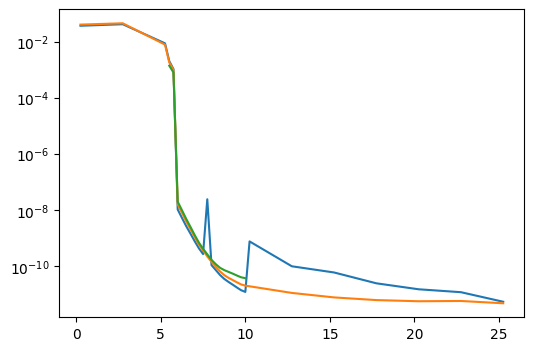

In [10]:
lbau = np.concatenate([delayau[0:3],
                       fillinau[:9],
                       delayau[[3]],
                       fillinau[9:],
                       delayau[4:]])
lbsrall = np.concatenate([lbsr[:,:,0:3],
                          lbsrf[:,:,:9],
                          lbsr[:,:,[3]],
                          lbsrf[:,:,9:],
                          lbsr[:,:,4:]], axis=2)
print(lbau.shape)
print(lbsrall.shape)

plt.figure(figsize=(6,4))
plt.semilogy(lbau, lbsrall[1,2,:])
plt.semilogy(dt2*delayvals2, superfine2)
plt.semilogy(dt4*delayvals4, superfine4)
plt.show()

In [12]:
# 3-21g and 6-31g basis set results
dt = 0.01
delayrangeH2 = np.arange(5,955+5,50)
print(delayrangeH2)
delayauH2 = dt*delayrangeH2
mbsrH2 = np.zeros((6, 20))
mbsrH2_321g = np.zeros((6, 20))
delayrangeHeH = np.arange(5,455+5,50)
print(delayrangeHeH)
delayauHeH = dt*delayrangeHeH
mbsrHeH = np.zeros((6, 10))
mbsrHeH_321g = np.zeros((6, 10))

[  5  55 105 155 205 255 305 355 405 455 505 555 605 655 705 755 805 855
 905 955]
[  5  55 105 155 205 255 305 355 405 455]


In [72]:
# load in mbsrH2
for j in range(6):
    gapstr = allgapstr[j]
    # if gapstr=='E2-E1':    # this one is in progress
    #     continue   
    freq = freqlookup['h2', '6-31g', gapstr]
    fname = 'fci_h2_6-31g_0.010000_' + freq + '_0.100000_5.txt'
    x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
    mbsrH2[j, :] = x[:, 1]
    freq = freqlookup['h2', '3-21g', gapstr]
    for i in range(delayrangeH2.shape[0]):
        fname = 'fci_h2_3-21g_0.010000_' + str(delayrangeH2[i]) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/3-21g/'+fname, skiprows=2, delimiter=',')
        mbsrH2_321g[j, i] = x[1]

# load in mbsrHeH
for j in range(6):
    gapstr = allgapstr[j]
    freq = freqlookup['heh+', '3-21g', gapstr]
    for i in range(delayrangeHeH.shape[0]):
        fname = 'fci_heh+_3-21g_0.010000_' + str(delayrangeHeH[i]) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/3-21g/'+fname, skiprows=2, delimiter=',')
        mbsrHeH_321g[j, i] = x[1]
    if gapstr=='E3-E2':    # this one is in perlgpu
        continue   
    freq = freqlookup['heh+', '6-31g', gapstr]
    fname = 'fci_heh+_6-31g_0.010000_' + freq + '_0.100000_5.txt'
    x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
    mbsrHeH[j, :] = x[:, 1]


In [64]:
# # load in mbsrH2
# for j in range(6):
#     gapstr = allgapstr[j]
#     if gapstr=='E2-E1':    # this one is in progress
#         continue   
#     freq = freqlookup['h2', '6-31g', gapstr]
#     fname = 'fci_h2_6-31g_0.010000_' + freq + '_0.100000_5.txt'
#     x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
#     mbsrH2[j, :] = x[:, 1]

# # load in mbsrHeH
# for j in range(6):
#     gapstr = allgapstr[j]
#     if gapstr=='E3-E2':    # this one is in perlgpu
#         continue   
#     freq = freqlookup['heh+', '6-31g', gapstr]
#     fname = 'fci_heh+_6-31g_0.010000_' + freq + '_0.100000_5.txt'
#     x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
#     mbsrHeH[j, :] = x[:, 1]

In [65]:
lastfreq = freqlookup['heh+', '6-31g', 'E3-E2']
j = allgapstr.index('E3-E2')
for i in range(10):
    fname = 'fci_heh+_6-31g_0.010000_' + str(delayrangeHeH[i]) + '_' + lastfreq + '_0.100000_5.txt'
    x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
    mbsrHeH[j, i] = x[1]

In [66]:
# small basis set results
dt = 0.01
delaysmallH2 = np.arange(40,440,40)
print(delaysmallH2)
delaysmallauH2 = dt*delaysmallH2
sbsrH2 = np.zeros((6, 10))
delaysmallHeH = np.arange(5,105,5)
print(delaysmallHeH)
delaysmallauHeH = dt*delaysmallHeH
sbsrHeH = np.zeros((6, 20))

[ 40  80 120 160 200 240 280 320 360 400]
[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100]


In [67]:
# small basis set results
i=0 # heh+
mol = molecules[i]
for j in range(6):
    freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
    for k in range(20):
        delay = delaysmallHeH[k]
        fname = 'fci_' + mol + '_sto-3g_0.010000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
        sbsrHeH[j, k] = x[1]

i=1 # h2
mol = molecules[i]
for j in range(6):
    freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
    for k in range(10):
        delay = delaysmallH2[k]
        fname = 'fci_' + mol + '_sto-3g_0.010000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
        sbsrH2[j, k] = x[1]

In [68]:
argsorts['h2', '6-31gss']

array([2, 5, 0, 4, 1, 3])

In [69]:
for j in argsorts['h2','6-31gss']:
    print(freqlookup['h2','6-31gss',allgapstr[j]])

0.023907
0.047784
0.063988
0.071691
0.087895
0.135679


[0.14285714 0.28571429 0.42857143 0.57142857 0.71428571 0.85714286]


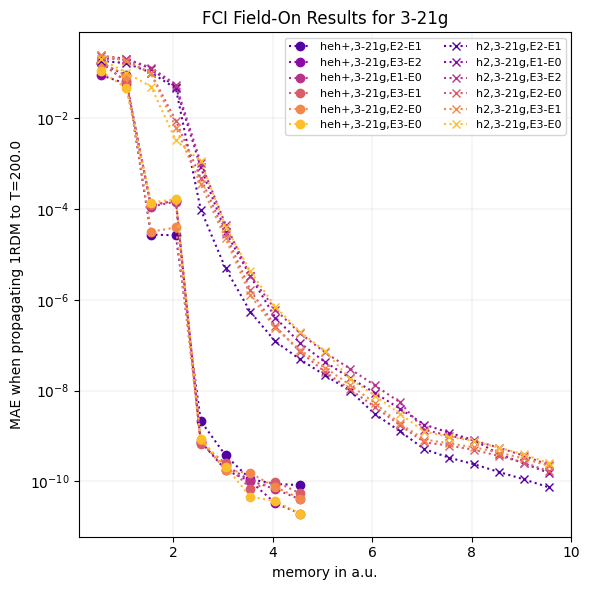

In [88]:
# try plasma colormap
# see https://matplotlib.org/stable/gallery/color/colormap_reference.html
# after this, cmap(0.5) will be the middle color in the color map
# also see https://matplotlib.org/stable/gallery/color/named_colors.html
cmap = matplotlib.colormaps['plasma']
cvals = np.linspace(0,1,8)[1:-1]
print(cvals)

plt.figure(figsize=(6,6))

# for i in range(2):
#     mol = molecules[i]
#     k=0
#     for j in argsorts[mol,'6-31gss']:
#         freq = freqlookup[mol, '6-31gss', allgapstr[j]]
#         print(freq)
#         if mol=='h2':
#             mrk = 'x'
#             ls = '-'
#         else:
#             mrk = 'o'
#             ls = '-'
#         if mol=='h2' and allgapstr[j]=='E2-E1':
#             plt.semilogy(dt2*delayvals2, superfine2, 
#                          label=mol+',6-31gss,'+gaplookup[mol,'6-31gss',freq], 
#                          marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         else:
#             plt.semilogy(lbau, lbsrall[i, j, :], 
#                          label=mol+',6-31gss,'+gaplookup[mol,'6-31gss',freq], 
#                          marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         k+=1

# for i in range(2):
#     mol = molecules[i]
#     k = 0
#     for j in argsorts[mol,'6-31g']:
#         freq = freqlookup[mol, '6-31g', allgapstr[j]]
#         if mol=='h2':
#             mrk = 'x'
#             ls = '-.'
#             plt.semilogy(delayauH2, mbsrH2[j, :], 
#                          label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
#                          marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         else:
#             mrk = 'o'
#             ls = '-.'
#             if j==5:
#                 plt.semilogy(delayauHeH[1:], mbsrHeH[j, 1:], 
#                              label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
#                              marker=mrk, linestyle=ls, color=cmap(cvals[k]))           
#             else:
#                 plt.semilogy(delayauHeH, mbsrHeH[j, :], 
#                              label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
#                              marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         k += 1

for i in range(2):
    mol = molecules[i]
    k = 0
    for j in argsorts[mol,'3-21g']:
        freq = freqlookup[mol, '3-21g', allgapstr[j]]
        if mol=='h2':
            mrk = 'x'
            ls = ':'
            plt.semilogy(delayauH2, mbsrH2_321g[j, :], 
                         label=mol+',3-21g,'+gaplookup[mol,'3-21g',freq], 
                         marker=mrk, linestyle=ls, color=cmap(cvals[k]))
        else:
            mrk = 'o'
            ls = ':'
            # if j==5:
            #     plt.semilogy(delayauHeH[1:], mbsrHeH[j, 1:], 
            #                  label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
            #                  marker=mrk, linestyle=ls, color=cmap(cvals[k]))           
            # else:
            plt.semilogy(delayauHeH, mbsrHeH_321g[j, :], 
                         label=mol+',3-21g,'+gaplookup[mol,'3-21g',freq], 
                         marker=mrk, linestyle=ls, color=cmap(cvals[k]))
        k += 1

# for i in range(2):
#     mol = molecules[i]
#     k = 0
#     for j in argsorts[mol,'sto-3g']:
#         freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
#         if mol=='h2':
#             mrk = 'x'
#             ls = ':'
#             plt.semilogy(delaysmallauH2, sbsrH2[j, :], 
#                          label=mol+',sto-3g,'+gaplookup[mol,'sto-3g',freq], 
#                          marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         else:
#             mrk = 'o'
#             ls = ':'
#             plt.semilogy(delaysmallauHeH, sbsrHeH[j, :], 
#                          label=mol+',sto-3g,'+gaplookup[mol,'sto-3g',freq], 
#                          marker=mrk, linestyle=ls, color=cmap(cvals[k]))
#         k += 1

plt.xlabel('memory in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=200.0')
plt.title('FCI Field-On Results for 3-21g')
plt.legend(loc="upper right", ncol=2, fontsize=8) # bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.grid(True, color='grey', linewidth=0.1)
plt.tight_layout()
plt.savefig('FCI_FO_3-21g.pdf')
plt.show()